In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

PROJECT_DIR = Path(r"C:\Users\adaly\OneDrive\Documents\DMDeficientGalaxyTNG-1")
CATALOG = PROJECT_DIR / "data" / "dmdg_catalog_z0.csv"
df = pd.read_csv(CATALOG)

print(f"Total catalog objects: {len(df):,}")
resolved = df[
    (df["N_star"] >= 500) &
    (df["SubhaloFlag"] == 1) &
    (df["f_DM"].notna())
].copy()

print(f"Resolved galaxies: {len(resolved):,}")
centrals = resolved[
    resolved["IsSatellite"] == False
].copy()
dmdgs = centrals[
    centrals["f_DM"] < 0.5
].copy()
dmdgs_non_extreme = dmdgs[
   dmdgs["f_DM"] > 0.05
].copy()
print(f"Centrals: {len(centrals):,}")
print(f"DMDGS (total): {len(dmdgs):,}")
print(f"DMDGS (non-tidal stripping): {len(dmdgs_non_extreme):,}")
print(f"DMDGS Fraction: {(len(dmdgs_non_extreme) / len(centrals)):,}")


Total catalog objects: 13,922,457
Resolved galaxies: 154,638
Centrals: 93,039
DMDGS (total): 96
DMDGS (non-tidal stripping): 96
DMDGS Fraction: 0.0010318253635572179
0.48631947
0.48631947


In [17]:
median = dmdgs["f_DM"].median()
print(median)
centralsMedian = centrals["f_DM"].median()
print(centralsMedian)
medianR = dmdgs["R_half_star"].median()
print(medianR)
centralsMedianR = centrals["R_half_star"].median()
print(centralsMedianR)

0.48631947
0.7412228
2.10108815
3.4186099


In [8]:

features = ["M_total_2Rh", "f_DM", "M_star"]
z_score_cols = []

for col in features:

    median_val = dmdgs[col].median()

    mad_val = (
        dmdgs[col] - median_val
    ).abs().median()

    if mad_val == 0:
        mad_val = dmdgs[col].std()

    z_col = f"{col}_z"

    dmdgs[z_col] = (
        (dmdgs[col] - median_val)
        / mad_val
    ).abs()

    z_score_cols.append(z_col)
dmdgs["total_distance"] = np.sqrt(
    (
        dmdgs[z_score_cols] ** 2
    ).sum(axis=1)
)

dmdgs_z_sorted = dmdgs.sort_values(
    by="total_distance"
)

representative = dmdgs_z_sorted.head(5)
print()
print("=" * 70)
print("FIVE REPRESENTATIVE DMDGs")
print("=" * 70)

print(
    representative[
        [
            "SubhaloID",
            "GroupID",
            "M_star",
            "M_total_2Rh",
            "f_DM",
            "R_half_star",
            "total_distance"
        ]
    ].to_string(index=False)
)
output_file = PROJECT_DIR / "data" / "representative_dmdgs.csv"

representative.to_csv(
    output_file,
    index=False
)

print()
print(f"Saved to:")
print(output_file)


FIVE REPRESENTATIVE DMDGs
 SubhaloID  GroupID   M_star  M_total_2Rh     f_DM  R_half_star  total_distance
   1603468    17403 2.442713     5.182994 0.488034     2.083286        0.428917
   1784604    30047 2.662195     5.193266 0.486302     2.703830        0.453012
   1763757    28223 2.175894     4.400174 0.489761     2.314904        0.465986
   1804523    31931 2.099484     4.272826 0.483848     2.035346        0.479435
   1723072    24978 2.805873     4.361835 0.489500     2.031300        0.503823

Saved to:
C:\Users\adaly\OneDrive\Documents\DMDeficientGalaxyTNG-1\data\representative_dmdgs.csv


In [8]:
import requests
from pathlib import Path
API_KEY = "6c8ec3d465c0bcf623a06a2b4c43408c "

SIM = "TNG300-1"
SNAP = 99
SUBHALO_ID = 1723072

output_dir = Path(
    r"C:\Users\adaly\OneDrive\Documents\DMDeficientGalaxyTNG-1\data\cutouts_099"
)
output_dir.mkdir(parents=True, exist_ok=True)

output_file = output_dir / f"subhalo_{SUBHALO_ID}_cutout.hdf5"

url = (
    f"https://www.tng-project.org/api/{SIM}/snapshots/{SNAP}"
    f"/subhalos/{SUBHALO_ID}/cutout.hdf5"
)

params = {
    "dm": "Coordinates",
    "stars": "Coordinates,Masses",
    "gas": "Coordinates,Masses",
}

headers = {
    "api-key": API_KEY
}

print("Requesting cutout...")
print(f"Subhalo: {SUBHALO_ID}")
print(f"URL: {url}")
print()

response = requests.get(
    url,
    params=params,
    headers=headers,
    stream=True,
    timeout=300
)

print("HTTP status:", response.status_code)

if response.status_code != 200:
    print(response.text)
    raise RuntimeError("Download failed.")

with open(output_file, "wb") as f:
    for chunk in response.iter_content(chunk_size=1024 * 1024):
        if chunk:
            f.write(chunk)

print()
print("Download complete!")
print("Saved to:")
print(output_file)

Requesting cutout...
Subhalo: 1723072
URL: https://www.tng-project.org/api/TNG300-1/snapshots/99/subhalos/1723072/cutout.hdf5

HTTP status: 200

Download complete!
Saved to:
C:\Users\adaly\OneDrive\Documents\DMDeficientGalaxyTNG-1\data\cutouts_099\subhalo_1723072_cutout.hdf5


In [9]:
import h5py
import numpy as np
import pandas as pd
from pathlib import Path

project_dir = Path(
    r"C:\Users\adaly\OneDrive\Documents\DMDeficientGalaxyTNG-1"
)

cutout_dir = project_dir / "data" / "cutouts_099"
catalog_file = project_dir / "data" / "representative_dmdgs.csv"

subhalo_ids = [
    1603468,
    1784604,
    1763757,
    1804523,
    1723072,
]
BOX_SIZE = 205000.0 

catalog = pd.read_csv(catalog_file)
catalog["SubhaloID"] = catalog["SubhaloID"].astype(int)

for subhalo_id in subhalo_ids:

    print("=" * 70)
    print(f"SUBHALO {subhalo_id}")
    print("=" * 70)

    row = catalog[catalog["SubhaloID"] == subhalo_id].iloc[0]
    center = np.array([
        row["x"],
        row["y"],
        row["z"]
    ])

    Rh = row["R_half_star"]

    print(f"Galaxy center: {center}")
    print(f"Stellar half-mass radius: {Rh:.4f} ckpc/h")
    print()

    filename = cutout_dir / f"subhalo_{subhalo_id}_cutout.hdf5"

    with h5py.File(filename, "r") as f:

        def get_radii(coords):
            delta = coords - center
            delta = delta - BOX_SIZE * np.round(delta / BOX_SIZE)

            return np.sqrt(np.sum(delta**2, axis=1))


        if "PartType1" in f:

            dm_coords = f["PartType1"]["Coordinates"][:]

            dm_r = get_radii(dm_coords)

            print(f"DM particles:     {len(dm_r)}")
            print(f"DM r min:         {dm_r.min():.4f}")
            print(f"DM r max:         {dm_r.max():.4f}")

        else:

            dm_r = np.array([])

            print("DM particles:     0")

        if "PartType4" in f:

            star_coords = f["PartType4"]["Coordinates"][:]

            star_r = get_radii(star_coords)

            print(f"Star particles:   {len(star_r)}")
            print(f"Star r min:       {star_r.min():.4f}")
            print(f"Star r max:       {star_r.max():.4f}")

        else:

            star_r = np.array([])

            print("Star particles:   0")

        if "PartType0" in f:

            gas_coords = f["PartType0"]["Coordinates"][:]

            gas_r = get_radii(gas_coords)

            print(f"Gas cells:        {len(gas_r)}")
            print(f"Gas r min:        {gas_r.min():.4f}")
            print(f"Gas r max:        {gas_r.max():.4f}")

        else:

            gas_r = np.array([])

            print("Gas cells:        0")
    print()
    print(f"2 × R_half = {2 * Rh:.4f} ckpc/h")

    dm_inside = np.sum(dm_r <= 2 * Rh)
    star_inside = np.sum(star_r <= 2 * Rh)
    gas_inside = np.sum(gas_r <= 2 * Rh)

    print()
    print("Particles/cells inside 2 R_half:")
    print(f"  DM:    {dm_inside}")
    print(f"  stars: {star_inside}")
    print(f"  gas:   {gas_inside}")

    print()

SUBHALO 1603468
Galaxy center: [ 65016.957 116226.87   36406.066]
Stellar half-mass radius: 2.0833 ckpc/h

DM particles:     31720
DM r min:         0.3135
DM r max:         333.6038
Star particles:   4580
Star r min:       0.0033
Star r max:       206.0085
Gas cells:        22131
Gas r min:        1.0318
Gas r max:        291.4234

2 × R_half = 4.1666 ckpc/h

Particles/cells inside 2 R_half:
  DM:    635
  stars: 3938
  gas:   630

SUBHALO 1784604
Galaxy center: [20434.232  9239.58  18386.291]
Stellar half-mass radius: 2.7038 ckpc/h

DM particles:     20947
DM r min:         0.1481
DM r max:         426.3566
Star particles:   4953
Star r min:       0.0014
Star r max:       158.9346
Gas cells:        11873
Gas r min:        0.8282
Gas r max:        413.7144

2 × R_half = 5.4077 ckpc/h

Particles/cells inside 2 R_half:
  DM:    634
  stars: 4175
  gas:   514

SUBHALO 1763757
Galaxy center: [62971.52   92704.19    7726.0566]
Stellar half-mass radius: 2.3149 ckpc/h

DM particles:     2170

In [10]:
import h5py
import numpy as np
import pandas as pd
from pathlib import Path
DM_PARTICLE_MASS = 0.00398342749867548
h = 0.6774
profile_dir = project_dir / "data" / "particle_profiles_099"
profile_dir.mkdir(parents=True, exist_ok=True)
all_profiles = []
for subhalo_id in subhalo_ids:

    print()
    print("=" * 70)
    print(f"MASS PROFILE: SUBHALO {subhalo_id}")
    print("=" * 70)

    row = catalog[catalog["SubhaloID"] == subhalo_id].iloc[0]

    center = np.array([
        row["x"],
        row["y"],
        row["z"]
    ])

    Rh = row["R_half_star"]
    catalog_dm_2Rh = row["M_DM_2Rh"]
    catalog_total_2Rh = row["M_total_2Rh"]

    filename = cutout_dir / f"subhalo_{subhalo_id}_cutout.hdf5"

    with h5py.File(filename, "r") as f:

        def get_radii(coords):

            delta = coords - center
            delta = delta - BOX_SIZE * np.round(delta / BOX_SIZE)

            return np.sqrt(np.sum(delta**2, axis=1))

        if "PartType1" in f:

            dm_coords = f["PartType1"]["Coordinates"][:]

            dm_r = get_radii(dm_coords)
            dm_mass = np.full(
                len(dm_r),
                DM_PARTICLE_MASS
            )

        else:

            dm_r = np.array([])
            dm_mass = np.array([])

        if "PartType4" in f:

            star_coords = f["PartType4"]["Coordinates"][:]
            star_mass = f["PartType4"]["Masses"][:]

            star_r = get_radii(star_coords)

        else:

            star_r = np.array([])
            star_mass = np.array([])

        if "PartType0" in f:

            gas_coords = f["PartType0"]["Coordinates"][:]
            gas_mass = f["PartType0"]["Masses"][:]

            gas_r = get_radii(gas_coords)

        else:

            gas_r = np.array([])
            gas_mass = np.array([])
    dm_order = np.argsort(dm_r)

    dm_r_sorted = dm_r[dm_order]
    dm_mass_sorted = dm_mass[dm_order]

    dm_cumulative = np.cumsum(dm_mass_sorted)
    star_order = np.argsort(star_r)

    star_r_sorted = star_r[star_order]
    star_mass_sorted = star_mass[star_order]

    star_cumulative = np.cumsum(star_mass_sorted)
    if len(gas_r) > 0:

        gas_order = np.argsort(gas_r)

        gas_r_sorted = gas_r[gas_order]
        gas_mass_sorted = gas_mass[gas_order]

        gas_cumulative = np.cumsum(gas_mass_sorted)

    else:

        gas_r_sorted = np.array([])
        gas_mass_sorted = np.array([])
        gas_cumulative = np.array([])

    r_aperture = 2.0 * Rh

    dm_mask = dm_r <= r_aperture
    star_mask = star_r <= r_aperture
    gas_mask = gas_r <= r_aperture

    particle_dm_2Rh = np.sum(dm_mass[dm_mask])
    particle_star_2Rh = np.sum(star_mass[star_mask])
    particle_gas_2Rh = np.sum(gas_mass[gas_mask])

    particle_total_2Rh = (
        particle_dm_2Rh
        + particle_star_2Rh
        + particle_gas_2Rh
    )

    print()
    print("MASS WITHIN 2 R_half")
    print("-" * 50)
    print("DM:")
    print(f"  particle = {particle_dm_2Rh:.6e}")
    print(f"  catalog  = {catalog_dm_2Rh:.6e}")

    print("Stars:")
    print(f"  particle = {particle_star_2Rh:.6e}")
    print("  catalog stellar mass is not currently stored")

    print("Gas:")
    print(f"  particle = {particle_gas_2Rh:.6e}")
    print()
    print("TOTAL:")
    print(f"  particle = {particle_total_2Rh:.6e}")
    print(f"  catalog  = {catalog_total_2Rh:.6e}")

    if catalog_dm_2Rh != 0:

        dm_difference = (
            particle_dm_2Rh - catalog_dm_2Rh
        ) / catalog_dm_2Rh

        print()
        print(
            f"DM fractional difference = "
            f"{dm_difference:+.3%}"
        )

    if catalog_total_2Rh != 0:

        total_difference = (
            particle_total_2Rh - catalog_total_2Rh
        ) / catalog_total_2Rh

        print(
            f"Total fractional difference = "
            f"{total_difference:+.3%}"
        )

    dm_r_kpc = dm_r_sorted / h
    star_r_kpc = star_r_sorted / h
    gas_r_kpc = gas_r_sorted / h

    max_length = max(
        len(dm_r_kpc),
        len(star_r_kpc),
        len(gas_r_kpc)
    )

    profile = pd.DataFrame({
        "SubhaloID": subhalo_id,

        "r_DM_kpc": pd.Series(
            np.pad(
                dm_r_kpc,
                (0, max_length - len(dm_r_kpc)),
                constant_values=np.nan
            )
        ),

        "M_DM_cumulative_1e10Msun_h": pd.Series(
            np.pad(
                dm_cumulative,
                (0, max_length - len(dm_cumulative)),
                constant_values=np.nan
            )
        ),

        "r_star_kpc": pd.Series(
            np.pad(
                star_r_kpc,
                (0, max_length - len(star_r_kpc)),
                constant_values=np.nan
            )
        ),

        "M_star_cumulative_1e10Msun_h": pd.Series(
            np.pad(
                star_cumulative,
                (0, max_length - len(star_cumulative)),
                constant_values=np.nan
            )
        ),
        "M_gas_cumulative_1e10Msun_h": pd.Series(
            np.pad(
                gas_cumulative,
                (0, max_length - len(gas_cumulative)),
                constant_values=np.nan
            )
        ),
    })

    # Add useful metadata
    profile["R_half_kpc"] = Rh / h
    profile["R_2half_kpc"] = 2 * Rh / h

    # Save individual profile
    output_file = (
        profile_dir /
        f"subhalo_{subhalo_id}_mass_profile.csv"
    )

    profile.to_csv(output_file, index=False)

    all_profiles.append(profile)

    print()
    print("Saved:")
    print(output_file)

print()
print("=" * 70)
print("ALL MASS PROFILES COMPLETE")
print("=" * 70)

print()
print(f"Profile files saved in:")
print(profile_dir)


MASS PROFILE: SUBHALO 1603468

MASS WITHIN 2 R_half
--------------------------------------------------
DM:
  particle = 2.529476e+00
  catalog  = 2.529476e+00
Stars:
  particle = 2.092607e+00
  catalog stellar mass is not currently stored
Gas:
  particle = 5.478495e-01

TOTAL:
  particle = 5.169932e+00
  catalog  = 5.182994e+00

DM fractional difference = +0.000%
Total fractional difference = -0.252%

Saved:
C:\Users\adaly\OneDrive\Documents\DMDeficientGalaxyTNG-1\data\particle_profiles_099\subhalo_1603468_mass_profile.csv

MASS PROFILE: SUBHALO 1784604

MASS WITHIN 2 R_half
--------------------------------------------------
DM:
  particle = 2.525493e+00
  catalog  = 2.525493e+00
Stars:
  particle = 2.229807e+00
  catalog stellar mass is not currently stored
Gas:
  particle = 4.266657e-01

TOTAL:
  particle = 5.181966e+00
  catalog  = 5.193266e+00

DM fractional difference = -0.000%
Total fractional difference = -0.218%

Saved:
C:\Users\adaly\OneDrive\Documents\DMDeficientGalaxyTNG-1\

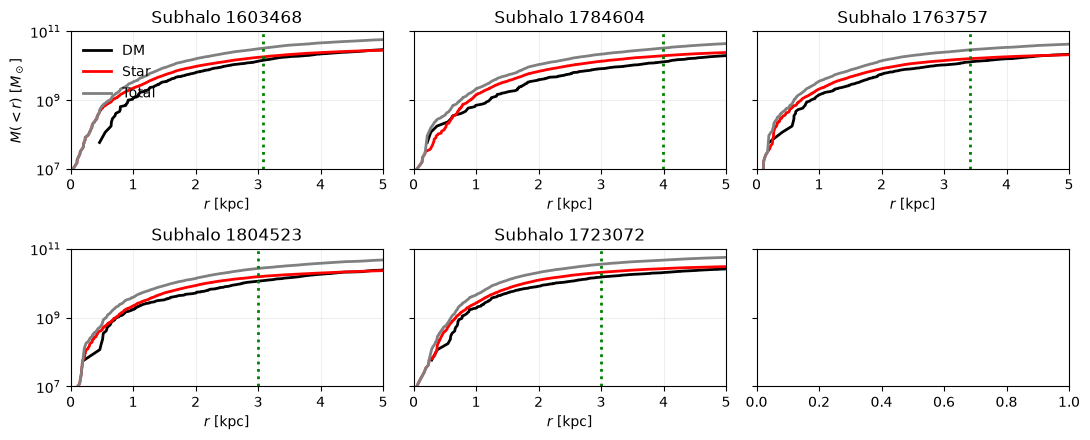


Saved:
C:\Users\adaly\OneDrive\Documents\DMDeficientGalaxyTNG-1\figures\mass_profiles_two_panel.png


In [14]:

import matplotlib.pyplot as plt

# Two representative galaxies
plot_ids = [
    1603468,
    1784604,
    1763757,
    1804523,
    1723072,
]

fig, axes = plt.subplots(
    2,
    3,
    figsize=(11, 4.5),
    sharey=True
)
axes = axes.flatten()

for ax, subhalo_id in zip(axes, plot_ids):


    profile_file = (
        profile_dir /
        f"subhalo_{subhalo_id}_mass_profile.csv"
    )

    profile = pd.read_csv(profile_file)

    dm_mask = profile["r_DM_kpc"].notna()

    r_dm = profile.loc[
        dm_mask,
        "r_DM_kpc"
    ].to_numpy()

    m_dm = profile.loc[
        dm_mask,
        "M_DM_cumulative_1e10Msun_h"
    ].to_numpy()
    m_dm = m_dm * 1e10 / h

    star_mask = profile["r_star_kpc"].notna()

    r_star = profile.loc[
        star_mask,
        "r_star_kpc"
    ].to_numpy()

    m_star = profile.loc[
        star_mask,
        "M_star_cumulative_1e10Msun_h"
    ].to_numpy()

    m_star = m_star * 1e10 / h


    all_radii = np.unique(
        np.concatenate([
            r_dm,
            r_star,
        ])
    )
    total_dm = np.interp(
        all_radii,
        r_dm,
        m_dm,
        left=0,
        right=m_dm[-1]
    )

    total_star = np.interp(
        all_radii,
        r_star,
        m_star,
        left=0,
        right=m_star[-1]
    )



    total_gas = np.zeros_like(all_radii)

    total_mass = (
        total_dm
        + total_star
        + total_gas
    )

    row = catalog[
        catalog["SubhaloID"] == subhalo_id
    ].iloc[0]

    Rh = row["R_half_star"] / h

    ax.plot(
        r_dm,
        m_dm,
        color="black",
        linewidth=2,
        label="DM"
    )

    ax.plot(
        r_star,
        m_star,
        color="red",
        linewidth=2,
        label="Star"
    )

    ax.plot(
        all_radii,
        total_mass,
        color="gray",
        linewidth=2,
        label="Total"
    )

    ax.axvline(
        Rh,
        color="green",
        linestyle=":",
        linewidth=2
    )

    ax.set_xscale("linear")

    ax.set_yscale("log")

    ax.set_xlim(0, 5)

    ax.set_ylim(
        1e7,
        1e11
    )

    ax.set_xlabel(r"$r$ [kpc]")

    ax.set_title(
        f"Subhalo {subhalo_id}"
    )

    ax.grid(
        True,
        which="both",
        alpha=0.2
    )
axes[0].set_ylabel(
    r"$M(<r)$ [$M_\odot$]"
)
axes[0].legend(
    loc="upper left",
    frameon=False
)

plt.tight_layout()

output_file = (
    project_dir
    / "figures"
    / "mass_profiles_two_panel.png"
)

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
for ax in axes[len(plot_ids):]:
    ax.set_visible(False)
print()
print("Saved:")
print(output_file)

In [48]:
import h5py
import pandas as pd
tree_file = r"C:\Users\adaly\OneDrive\Documents\DMDeficientGalaxyTNG-1\data\TNG300-1\output\tree_1763757.hdf5"

with h5py.File(tree_file, "r") as f:
    tree = pd.DataFrame({
        "TreeID": f["TreeID"][:],
        "SnapNum": f["SnapNum"][:],
        "SubhaloID": f["SubhaloID"][:],
        "SubfindID": f["SubfindID"][:],
        "FirstProgenitorID": f["FirstProgenitorID"][:],
        "NextProgenitorID": f["NextProgenitorID"][:],
        "DescendantID": f["DescendantID"][:],
        "SubhaloMass": f["SubhaloMass"][:],
        "SubhaloMassInRad": f["SubhaloMassInRad"][:],
        "SubhaloHalfmassRad": f["SubhaloHalfmassRad"][:],
    })

print(tree.sort_values("SnapNum").to_string(index=False))

            TreeID  SnapNum          SubhaloID  SubfindID  FirstProgenitorID   NextProgenitorID       DescendantID  SubhaloMass  SubhaloMassInRad  SubhaloHalfmassRad
360000006700000000        6 360000006700004893    1575161                 -1                 -1 360000006700004892     0.123220          0.000000           23.982134
360000006700000000        7 360000006700004892    1758099 360000006700004893                 -1 360000006700004891     0.154288          0.000000           21.451569
360000006700000000        8 360000006700004891    1099324 360000006700004892                 -1 360000006700004890     0.252603          0.000000           18.688301
360000006700000000        9 360000006700004890    1831546 360000006700004891                 -1 360000006700004889     0.228821          0.000000           16.591522
360000006700000000       10 360000006700004889    1285124 360000006700004890                 -1 360000006700004888     0.349289          0.000000           21.067247
3600

In [49]:
import numpy as np

tree_file = r"C:\Users\adaly\OneDrive\Documents\DMDeficientGalaxyTNG-1\data\TNG300-1\output\tree_1763757.hdf5"

with h5py.File(tree_file, "r") as f:
    snap = f["SnapNum"][:]
    subhalo_id = f["SubhaloID"][:]
    subhalo_mass = f["SubhaloMass"][:]
    subhalo_mass_in_rad = f["SubhaloMassInRad"][:]
    halfmass_rad = f["SubhaloHalfmassRad"][:]
    group_id = f["SubhaloGrNr"][:]
    mass_type = f["SubhaloMassType"][:]
    mass_in_rad_type = f["SubhaloMassInRadType"][:]
    gas_mass = mass_type[:, 0]
    dm_mass = mass_type[:, 1]
    star_mass = mass_type[:, 4]

    gas_mass_in_rad = mass_in_rad_type[:, 0]
    dm_mass_in_rad = mass_in_rad_type[:, 1]
    star_mass_in_rad = mass_in_rad_type[:, 4]
tree = pd.DataFrame({
    "SnapNum": snap,
    "SubhaloID": subhalo_id,
    "SubhaloMass": subhalo_mass,
    "SubhaloMassInRad": subhalo_mass_in_rad,
    "GasMass": gas_mass,
    "DMMass": dm_mass,
    "StarMass": star_mass,
    "GasMassInRad": gas_mass_in_rad,
    "DMMassInRad": dm_mass_in_rad,
    "StarMassInRad": star_mass_in_rad,
    "HalfmassRad": halfmass_rad,
    "GroupID": group_id
})
tree["f_DM"] = (
    tree["DMMassInRad"] /
    tree["SubhaloMassInRad"]
)

tree = tree.sort_values("SnapNum")

print(tree.to_string(index=False))

 SnapNum          SubhaloID  SubhaloMass  SubhaloMassInRad   GasMass    DMMass  StarMass  GasMassInRad  DMMassInRad  StarMassInRad  HalfmassRad  GroupID     f_DM
       6 360000006700004893     0.123220          0.000000  0.015668  0.107553  0.000000      0.000000     0.000000       0.000000    23.982134  1510211      NaN
       7 360000006700004892     0.154288          0.000000  0.018851  0.135437  0.000000      0.000000     0.000000       0.000000    21.451569  1646615      NaN
       8 360000006700004891     0.252603          0.000000  0.037498  0.215105  0.000000      0.000000     0.000000       0.000000    18.688301   934557      NaN
       9 360000006700004890     0.228821          0.000000  0.029649  0.199171  0.000000      0.000000     0.000000       0.000000    16.591522  1608306      NaN
      10 360000006700004889     0.349289          0.000000  0.046548  0.302740  0.000000      0.000000     0.000000       0.000000    21.067247  1001452      NaN
      11 360000006700004888 

In [50]:
import requests
url = "https://www.tng-project.org/api/TNG300-1/snapshots/"
headers = {"api-key": "6c8ec3d465c0bcf623a06a2b4c43408c"}
response = requests.get(url, headers=headers)
response.raise_for_status()

snapshots = response.json()
snapshot_redshift = {
    snap["number"]: snap["redshift"]
    for snap in snapshots
}
tree["Redshift"] = tree["SnapNum"].map(snapshot_redshift)
print(
    tree[
        ["SnapNum", "Redshift", "SubhaloID", "f_DM"]
    ].to_string(index=False)
)

tree["Redshift"] = tree["SnapNum"].map(snapshot_redshift)

print(
    tree[
        ["SnapNum", "Redshift", "SubhaloID", "f_DM"]
    ].to_string(index=False)
)

 SnapNum     Redshift          SubhaloID     f_DM
       6 9.002340e+00 360000006700004893      NaN
       7 8.449476e+00 360000006700004892      NaN
       8 8.012173e+00 360000006700004891      NaN
       9 7.595107e+00 360000006700004890      NaN
      10 7.236276e+00 360000006700004889      NaN
      11 7.005417e+00 360000006700004888      NaN
      12 6.491598e+00 360000006700004887      NaN
      13 6.010757e+00 360000006700004886      NaN
      14 5.846614e+00 360000006700004885      NaN
      15 5.529766e+00 360000006700004884      NaN
      16 5.227581e+00 360000006700004883      NaN
      17 4.995933e+00 360000006700004882      NaN
      18 4.664518e+00 360000006700004881      NaN
      19 4.428034e+00 360000006700004880 0.910330
      20 4.176835e+00 360000006700004879 0.926916
      21 4.007945e+00 360000006700004878 0.892582
      22 3.708774e+00 360000006700004877 0.884351
      23 3.490861e+00 360000006700004876 0.886525
      24 3.283033e+00 360000006700004875 0.910692


4    0.502645
3    0.511247
2    0.478572
1    0.456908
0    0.489761
Name: f_DM, dtype: float32
11    0.141876
5     0.058507
4     0.048524
Name: Redshift, dtype: float64
11    0.506357
5     0.498278
4     0.502645
Name: f_DM, dtype: float32


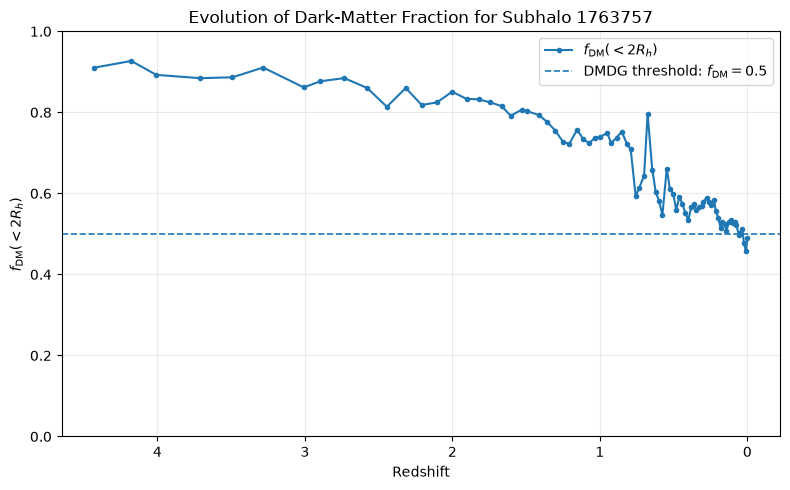

In [51]:
import matplotlib.pyplot as plt

crossings = tree[
    (tree["f_DM"] > 0.49) &
    (tree["f_DM"] < 0.51)
].copy()

end = tree[
    tree["Redshift"] < 0.05
].copy()

print(end["f_DM"])
print(crossings["Redshift"])
print(crossings["f_DM"])

plot_data = tree.dropna(
    subset=["Redshift", "f_DM"]
).copy()

plot_data = plot_data.sort_values(
    "Redshift",
    ascending=False
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    plot_data["Redshift"],
    plot_data["f_DM"],
    marker="o",
    markersize=3,
    linewidth=1.5,
    label=r"$f_{\rm DM}(<2R_h)$"
)

ax.axhline(
    0.5,
    linestyle="--",
    linewidth=1.2,
    label=r"DMDG threshold: $f_{\rm DM}=0.5$"
)

ax.invert_xaxis()

ax.set_xlabel("Redshift")
ax.set_ylabel(r"$f_{\rm DM}(<2R_h)$")

ax.set_title(
    "Evolution of Dark-Matter Fraction for Subhalo 1763757"
)

ax.set_ylim(0, 1)

ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

In [53]:
import requests
import h5py
import pandas as pd
import numpy as np
from pathlib import Path

# ============================================================
# SETTINGS
# ============================================================

API_KEY = "6c8ec3d465c0bcf623a06a2b4c43408c"

target_id = 1603468
target_snap = 99

headers = {
    "api-key": API_KEY
}

# ============================================================
# 1. DOWNLOAD THE MAIN PROGENITOR BRANCH
# ============================================================

mpb_url = (
    f"https://www.tng-project.org/api/"
    f"TNG300-1/snapshots/{target_snap}/subhalos/{target_id}/sublink/mpb.hdf5"
)

response = requests.get(mpb_url, headers=headers)
response.raise_for_status()

with open("tree.hdf5", "wb") as f:
    f.write(response.content)

print("Downloaded main progenitor branch.")


# ============================================================
# 2. READ THE MAIN PROGENITOR BRANCH
# ============================================================

with h5py.File("tree.hdf5", "r") as hdf:
    snap_nums = hdf["SnapNum"][:]
    subfind_ids = hdf["SubfindID"][:]
    masses = hdf["SubhaloMass"][:]

# Create lookup:
# snapshot -> primary subhalo ID + mass
primary_lookup = {}

for snap, subhalo_id, mass in zip(
    snap_nums,
    subfind_ids,
    masses
):
    primary_lookup[int(snap)] = {
        "SubhaloID": int(subhalo_id),
        "Mass": float(mass)
    }

print(f"Main progenitor branch contains {len(primary_lookup)} snapshots.")


# ============================================================
# 3. GET THE SIMPLE TREE FOR THE TARGET
# ============================================================

simple_url = (
    f"https://www.tng-project.org/api/"
    f"TNG300-1/snapshots/{target_snap}/subhalos/"
    f"{target_id}/sublink/simple.json"
)

response = requests.get(simple_url, headers=headers)
response.raise_for_status()

simple_tree = response.json()

mergers = simple_tree.get("Mergers", [])

print(f"\nNumber of merger events: {len(mergers)}")


# ============================================================
# 4. FUNCTION TO GET SECONDARY MASS
# ============================================================

def get_subhalo_mass(snap, subhalo_id):
    """
    Get the total bound SubhaloMass for a subhalo
    at a specific snapshot.
    """

    url = (
        f"https://www.tng-project.org/api/"
        f"TNG300-1/snapshots/{snap}/subhalos/{subhalo_id}/"
    )

    response = requests.get(url, headers=headers)
    response.raise_for_status()

    data = response.json()

    return data["mass"]


# ============================================================
# 5. CALCULATE MERGER MASS RATIOS
# ============================================================

merger_results = []

for snap, secondary_id in mergers:

    snap = int(snap)
    secondary_id = int(secondary_id)

    # --------------------------------------------------------
    # Primary
    # --------------------------------------------------------

    if snap not in primary_lookup:
        print(
            f"Skipping merger at snap {snap}: "
            f"primary not found in main progenitor branch."
        )
        continue

    primary_id = primary_lookup[snap]["SubhaloID"]
    primary_mass = primary_lookup[snap]["Mass"]

    # --------------------------------------------------------
    # Secondary
    # --------------------------------------------------------

    try:
        secondary_mass = get_subhalo_mass(
            snap,
            secondary_id
        )
    except Exception as e:
        print(
            f"Could not retrieve secondary "
            f"{secondary_id} at snap {snap}: {e}"
        )
        continue

    # --------------------------------------------------------
    # Mass ratio
    # --------------------------------------------------------

    if primary_mass > 0:
        mass_ratio = secondary_mass / primary_mass
    else:
        mass_ratio = np.nan

    # --------------------------------------------------------
    # Classification
    # --------------------------------------------------------

    if mass_ratio >= 0.25:
        merger_type = "Major"
    elif mass_ratio >= 0.10:
        merger_type = "Minor"
    else:
        merger_type = "Very minor"

    merger_results.append({
        "SnapNum": snap,
        "PrimarySubhaloID": primary_id,
        "SecondarySubhaloID": secondary_id,
        "PrimaryMass": primary_mass,
        "SecondaryMass": secondary_mass,
        "MassRatio": mass_ratio,
        "MergerType": merger_type
    })


# ============================================================
# 6. PUT EVERYTHING INTO A DATAFRAME
# ============================================================

merger_df = pd.DataFrame(merger_results)

if len(merger_df) > 0:

    merger_df = merger_df.sort_values(
        "SnapNum",
        ascending=False
    ).reset_index(drop=True)

    print("\n" + "=" * 80)
    print("MERGER HISTORY")
    print("=" * 80)

    print(
        merger_df.to_string(
            index=False,
            float_format=lambda x: f"{x:.4e}"
        )
    )

else:
    print("\nNo merger events were found.")


# ============================================================
# 7. SUMMARY
# ============================================================

if len(merger_df) > 0:

    print("\n" + "=" * 80)
    print("MERGER SUMMARY")
    print("=" * 80)

    print(
        f"Total mergers: "
        f"{len(merger_df)}"
    )

    print(
        f"Major mergers: "
        f"{(merger_df['MergerType'] == 'Major').sum()}"
    )

    print(
        f"Minor mergers: "
        f"{(merger_df['MergerType'] == 'Minor').sum()}"
    )

    print(
        f"Very minor mergers: "
        f"{(merger_df['MergerType'] == 'Very minor').sum()}"
    )

    print(
        f"Largest mass ratio: "
        f"{merger_df['MassRatio'].max():.4f}"
    )


# ============================================================
# 8. SAVE THE MERGER HISTORY
# ============================================================

merger_df.to_csv(
    "merger_history_738558.csv",
    index=False
)

print("\nSaved to merger_history_738558.csv")

Downloaded main progenitor branch.
Main progenitor branch contains 97 snapshots.

Number of merger events: 58

MERGER HISTORY
 SnapNum  PrimarySubhaloID  SecondarySubhaloID  PrimaryMass  SecondaryMass  MassRatio MergerType
      98           1596600             1596617   1.4622e+02     9.5602e-02 6.5383e-04 Very minor
      98           1596600             1596619   1.4622e+02     8.3652e-02 5.7210e-04 Very minor
      96           1580168             1580189   1.4380e+02     8.7635e-02 6.0943e-04 Very minor
      96           1580168             1580190   1.4380e+02     8.7635e-02 6.0943e-04 Very minor
      95           1573749             1573766   1.3821e+02     1.2614e-01 9.1267e-04 Very minor
      94           1566220             1566245   1.3514e+02     7.9669e-02 5.8952e-04 Very minor
      93           1553402             1553428   1.3096e+02     7.9669e-02 6.0833e-04 Very minor
      90           1538587             1538611   1.1797e+02     9.1619e-02 7.7666e-04 Very minor
 

In [54]:
import pandas as pd
import numpy as np
import h5py
tree_file = r"C:\Users\adaly\OneDrive\Documents\DMDeficientGalaxyTNG-1\data\TNG300-1\output\tree_1603468.hdf5"


with h5py.File(tree_file, "r") as f:
    snap = f["SnapNum"][:]
    subhalo_id = f["SubhaloID"][:]
    subhalo_mass = f["SubhaloMass"][:]
    subhalo_mass_in_rad = f["SubhaloMassInRad"][:]
    halfmass_rad = f["SubhaloHalfmassRad"][:]
    group_id = f["SubhaloGrNr"][:]
    mass_type = f["SubhaloMassType"][:]
    mass_in_rad_type = f["SubhaloMassInRadType"][:]
    gas_mass = mass_type[:, 0]
    dm_mass = mass_type[:, 1]
    star_mass = mass_type[:, 4]

    gas_mass_in_rad = mass_in_rad_type[:, 0]
    dm_mass_in_rad = mass_in_rad_type[:, 1]
    star_mass_in_rad = mass_in_rad_type[:, 4]
tree = pd.DataFrame({
    "SnapNum": snap,
    "SubhaloID": subhalo_id,
    "SubhaloMass": subhalo_mass,
    "SubhaloMassInRad": subhalo_mass_in_rad,
    "GasMass": gas_mass,
    "DMMass": dm_mass,
    "StarMass": star_mass,
    "GasMassInRad": gas_mass_in_rad,
    "DMMassInRad": dm_mass_in_rad,
    "StarMassInRad": star_mass_in_rad,
    "HalfmassRad": halfmass_rad,
    "GroupID": group_id
})
tree["f_DM"] = (
    tree["DMMassInRad"] /
    tree["SubhaloMassInRad"]
)
import requests
url = "https://www.tng-project.org/api/TNG300-1/snapshots/"
headers = {"api-key": "6c8ec3d465c0bcf623a06a2b4c43408c"}
response = requests.get(url, headers=headers)
response.raise_for_status()

snapshots = response.json()
snapshot_redshift = {
    snap["number"]: snap["redshift"]
    for snap in snapshots
}
tree["Redshift"] = tree["SnapNum"].map(snapshot_redshift)
print(
    tree[
        ["SnapNum", "Redshift", "SubhaloID", "f_DM"]
    ].to_string(index=False)
)

tree["Redshift"] = tree["SnapNum"].map(snapshot_redshift)

print(
    tree[
        ["SnapNum", "Redshift", "SubhaloID", "f_DM"]
    ].to_string(index=False)
)
event_data = tree.dropna(
    subset=["Redshift", "f_DM"]
).copy()

event_data = event_data.sort_values("SnapNum").reset_index(drop=True)
event_data["Delta_f_DM"] = event_data["f_DM"].diff()
biggest_drops = event_data.sort_values(
    "Delta_f_DM"
).head(10)

print(
    biggest_drops[
        [
            "SnapNum",
            "Redshift",
            "SubhaloID",
            "f_DM",
            "Delta_f_DM",
            "DMMass",
            "StarMass",
            "GasMass",
            "HalfmassRad",
            "GroupID"
        ]
    ].to_string(index=False)
)
event_data["Delta_DM"] = event_data["DMMass"].diff()
event_data["Delta_star"] = event_data["StarMass"].diff()
event_data["Delta_gas"] = event_data["GasMass"].diff()

event_data["FracChange_DM"] = (
    event_data["DMMass"].diff() /
    event_data["DMMass"].shift(1)
)

event_data["FracChange_star"] = (
    event_data["StarMass"].diff() /
    event_data["StarMass"].shift(1)
)

event_data["FracChange_gas"] = (
    event_data["GasMass"].diff() /
    event_data["GasMass"].shift(1)
)
biggest_drops = event_data.sort_values(
    "Delta_f_DM"
).head(10)

print(
    biggest_drops[
        [
            "SnapNum",
            "Redshift",
            "SubhaloID",
            "f_DM",
            "Delta_f_DM",
            "FracChange_DM",
            "FracChange_star",
            "FracChange_gas",
            "HalfmassRad"
        ]
    ].to_string(index=False)
)


 SnapNum     Redshift          SubhaloID     f_DM
      99 2.220446e-16 350000086200005271 0.488034
      98 9.521667e-03 350000086200005272 0.489985
      97 2.397443e-02 350000086200005273 0.492449
      96 3.372437e-02 350000086200005274 0.490059
      95 4.852363e-02 350000086200005275 0.485881
      94 5.850732e-02 350000086200005276 0.484751
      93 7.366138e-02 350000086200005277 0.492732
      92 8.388443e-02 350000086200005278 0.515317
      91 9.940180e-02 350000086200005279 0.490876
      90 1.098699e-01 350000086200005280 0.500390
      89 1.257593e-01 350000086200005281 0.503670
      88 1.418762e-01 350000086200005282 0.500371
      87 1.527488e-01 350000086200005283 0.496637
      86 1.692520e-01 350000086200005284 0.490148
      85 1.803853e-01 350000086200005285 0.488718
      84 1.972842e-01 350000086200005286 0.491750
      83 2.144250e-01 350000086200005287 0.511509
      82 2.259884e-01 350000086200005288 0.502301
      81 2.435402e-01 350000086200005289 0.510286
